### Report Plot

C:\Users\chris\anaconda3\envs\ddw_env\lib\site-packages\lightning_utilities\core\imports.py:10: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
C:\Users\chris\AppData\Local\Temp\ipykernel_6472\998193621.py:59: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  fig.subplots_adjust(wspace=0.25)


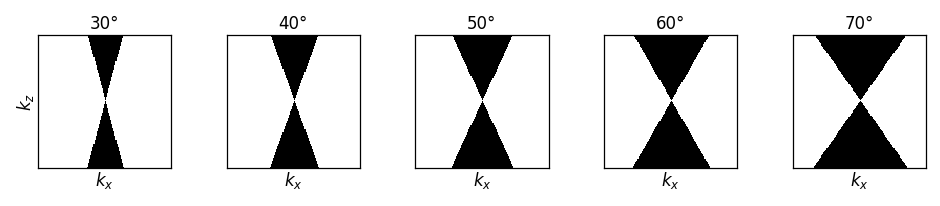

In [1]:
import torch
import matplotlib.pyplot as plt
from ddw.utils.missing_wedge import get_missing_wedge_mask
from pathlib import Path

plt.rcParams.update({
    "font.size": 8,
    "axes.labelsize": 8,
    "axes.titlesize": 8,
    "figure.dpi": 150,
    "savefig.dpi": 300,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

angles = [30, 40, 50, 60, 70]
grid_size = (128, 128, 128)

cm = 1 / 2.54
fig, axes = plt.subplots(
    1, len(angles),
    figsize=(16 * cm, 3.2 * cm),
    constrained_layout=True
)


for i, (ax, angle) in enumerate(zip(axes, angles)):
    mask = get_missing_wedge_mask(grid_size, mw_angle=angle)
    mid_y = mask.shape[1] // 2
    sl = mask[:, mid_y, :].numpy()

    ax.imshow(
        sl,
        cmap="gray",
        origin="lower",
        vmin=0,
        vmax=1,
        extent=[-1, 1, -1, 1],
        interpolation="nearest"
    )

    ax.set_title(f"{angle}°", pad=3)
    ax.set_aspect("equal")

    ax.set_xlabel(r"$k_x$", labelpad=1)

    if i == 0:
        ax.set_ylabel(r"$k_z$", labelpad=1)
    else:
        ax.set_ylabel("")

    # clean schematic axes: no numerical tick labels
    ax.set_xticks([])
    ax.set_yticks([])

    for spine in ax.spines.values():
        spine.set_linewidth(0.6)

fig.subplots_adjust(wspace=0.25)

### Adjust Figure for report

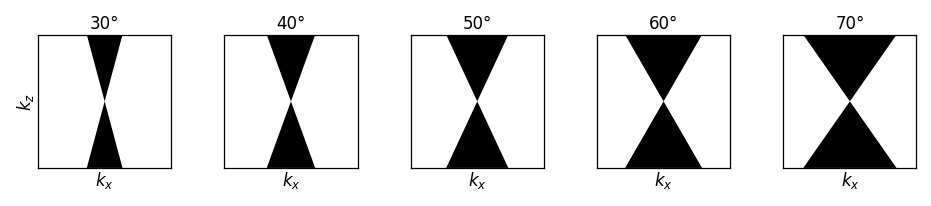

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon

plt.rcParams.update({
    "font.size": 8,
    "axes.labelsize": 8,
    "axes.titlesize": 8,
    "figure.dpi": 150,
    "savefig.dpi": 300,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

angles = [30, 40, 50, 60, 70]

cm = 1 / 2.54
fig, axes = plt.subplots(
    1, len(angles),
    figsize=(16 * cm, 3.2 * cm),
    constrained_layout=True
)

for i, (ax, angle) in enumerate(zip(axes, angles)):
    ax.set_facecolor("white")

    # Width of wedge at top/bottom boundary.
    # This gives a clean schematic similar to your current plot.
    half_width = np.tan(np.deg2rad(angle / 2))
    half_width = min(half_width, 1.0)

    top_wedge = Polygon(
        [(-half_width, 1), (half_width, 1), (0, 0)],
        closed=True,
        facecolor="black",
        edgecolor="black",
        linewidth=0
    )

    bottom_wedge = Polygon(
        [(-half_width, -1), (half_width, -1), (0, 0)],
        closed=True,
        facecolor="black",
        edgecolor="black",
        linewidth=0
    )

    ax.add_patch(top_wedge)
    ax.add_patch(bottom_wedge)

    ax.set_xlim(-1, 1)
    ax.set_ylim(-1, 1)
    ax.set_aspect("equal")

    ax.set_title(f"{angle}°", pad=3)
    ax.set_xlabel(r"$k_x$", labelpad=1)

    if i == 0:
        ax.set_ylabel(r"$k_z$", labelpad=1)

    ax.set_xticks([])
    ax.set_yticks([])

    for spine in ax.spines.values():
        spine.set_linewidth(0.6)

plt.show()

In [3]:
export_dir = Path("../../figures/final_report")

save_png = export_dir / f"Missing_Wedge_Visual.png"
save_pdf = export_dir / f"Missing_Wedge_Visual.pdf"

fig.savefig(
    save_png,
    dpi=300,
    bbox_inches="tight",
    pad_inches=0.03,
    facecolor="white"
)

fig.savefig(
    save_pdf,
    bbox_inches="tight",
    pad_inches=0.03,
    facecolor="white"
)

print("Saved:", save_png)
print("Saved:", save_pdf)

Saved: ..\..\figures\final_report\Missing_Wedge_Visual.png
Saved: ..\..\figures\final_report\Missing_Wedge_Visual.pdf


In [4]:
angle = 50
mask = get_missing_wedge_mask((128, 128, 128), mw_angle=angle)

fraction_ones = mask.float().mean().item()
fraction_zeros = 1 - fraction_ones

print(f"mw_angle = {angle}°")
print(f"Fraction mask == 1: {fraction_ones:.4f}")
print(f"Fraction mask == 0: {fraction_zeros:.4f}")

mw_angle = 50°
Fraction mask == 1: 0.7673
Fraction mask == 0: 0.2327


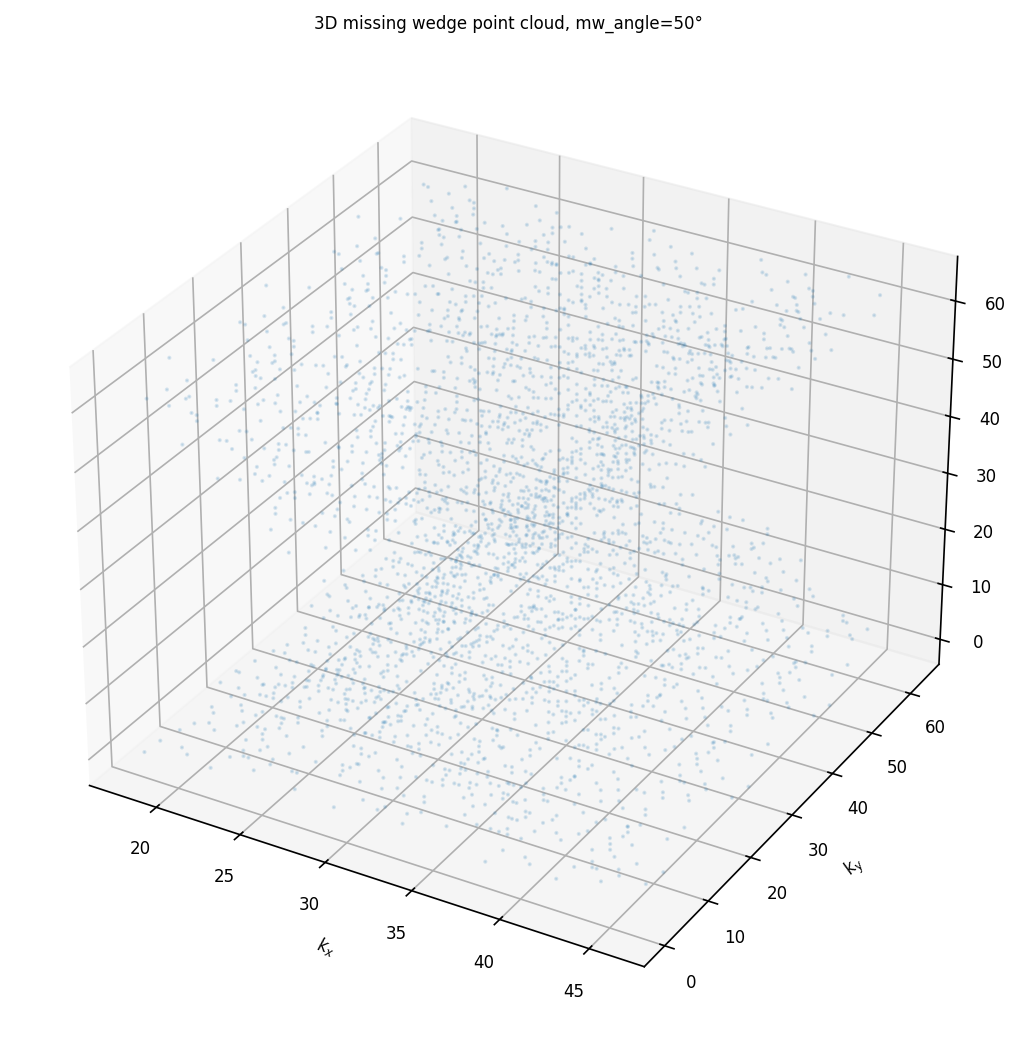

In [5]:
import torch
import matplotlib.pyplot as plt
from ddw.utils.missing_wedge import get_missing_wedge_mask

angle = 50
grid_size = (64, 64, 64)

mask = get_missing_wedge_mask(grid_size, mw_angle=angle)

# Tensor order is [z, y, x].
# We plot the zero-region as the missing wedge if mask is a keep-mask.
# If this looks inverted, switch missing = mask.
missing = 1 - mask

z, y, x = torch.where(missing > 0)

# Downsample points so plotting stays fast
step = 20
z = z[::step]
y = y[::step]
x = x[::step]

fig = plt.figure(figsize=(7, 7))
ax = fig.add_subplot(111, projection="3d")

ax.scatter(x.numpy(), y.numpy(), z.numpy(), s=1, alpha=0.15)

ax.set_title(f"3D missing wedge point cloud, mw_angle={angle}°")
ax.set_xlabel("$k_x$")
ax.set_ylabel("$k_y$")
ax.set_zlabel("$k_z$")

plt.tight_layout()
plt.show()

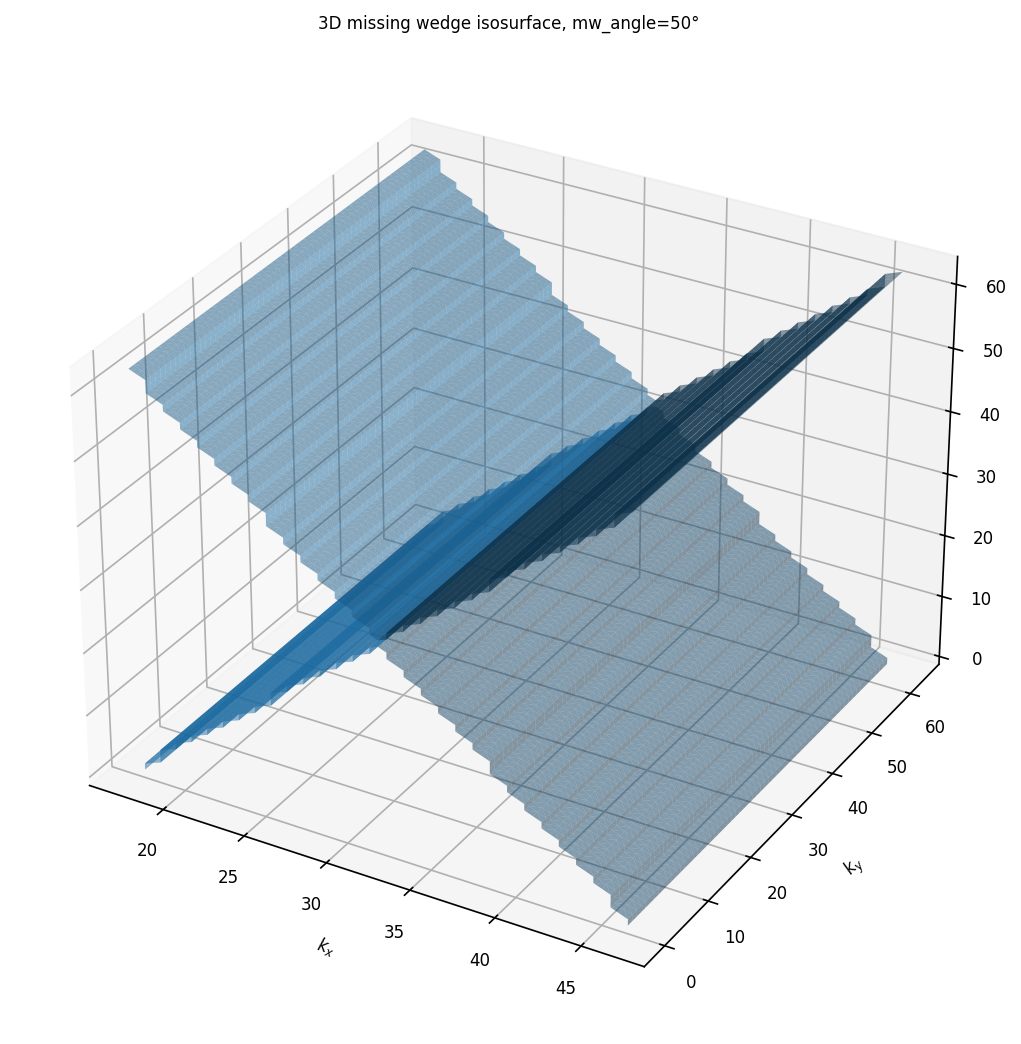

In [6]:
import torch
import matplotlib.pyplot as plt
from skimage import measure
from ddw.utils.missing_wedge import get_missing_wedge_mask

angle = 50
grid_size = (64, 64, 64)

mask = get_missing_wedge_mask(grid_size, mw_angle=angle)
missing = (1 - mask).numpy().astype(float)

verts, faces, normals, values = measure.marching_cubes(missing, level=0.5)

fig = plt.figure(figsize=(7, 7))
ax = fig.add_subplot(111, projection="3d")

ax.plot_trisurf(
    verts[:, 2],  # x
    verts[:, 1],  # y
    faces,
    verts[:, 0],  # z
    linewidth=0.1,
    alpha=0.5
)

ax.set_title(f"3D missing wedge isosurface, mw_angle={angle}°")
ax.set_xlabel("$k_x$")
ax.set_ylabel("$k_y$")
ax.set_zlabel("$k_z$")

plt.tight_layout()
plt.show()

In [7]:
#fig.savefig("missing_wedge_masks_3d_isosurface.png", dpi=200, bbox_inches="tight")

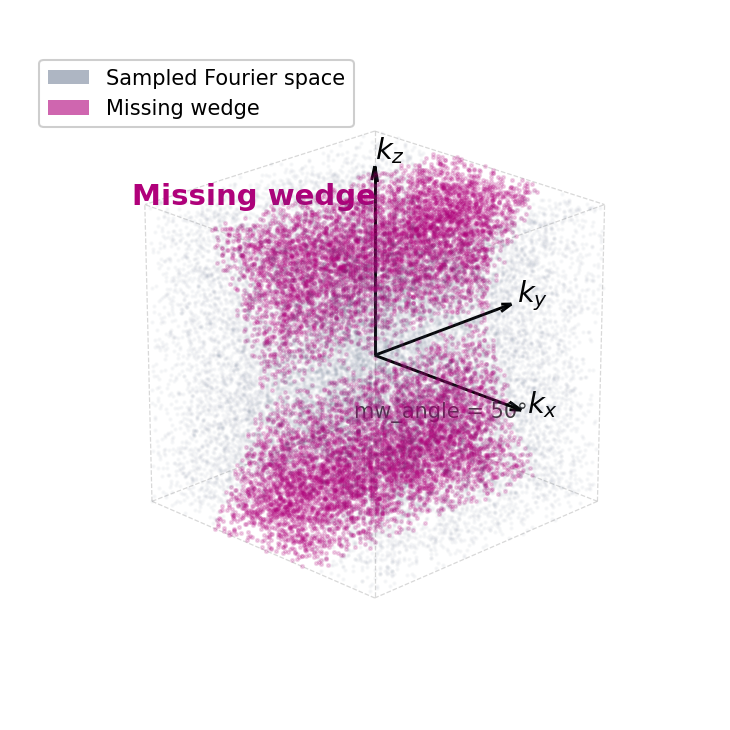

In [8]:
# Presentation-ready 3D missing wedge figure
# Append this cell at the end of Missing_Wedge_Visualization.ipynb

import numpy as np
import torch
import matplotlib.pyplot as plt
from pathlib import Path
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
from matplotlib.patches import Patch
from ddw.utils.missing_wedge import get_missing_wedge_mask

# -----------------------------
# Settings
# -----------------------------
angle = 50
grid_size = (96, 96, 96)   # [z, y, x]
export_dir = Path("../../figures/final_presentation")
export_dir.mkdir(parents=True, exist_ok=True)

save_png = export_dir / f"missing_wedge_3D_{angle}deg.png"
save_pdf = export_dir / f"missing_wedge_3D_{angle}deg.pdf"

# -----------------------------
# Load DDW missing wedge mask
# -----------------------------
mask = get_missing_wedge_mask(grid_size, mw_angle=angle)

# In DDW convention: mask = 1 means sampled/kept, mask = 0 means missing
missing = (1 - mask).cpu().numpy().astype(bool)

# Coordinates in normalized Fourier space
nz, ny, nx = grid_size
kz = np.linspace(-1, 1, nz)
ky = np.linspace(-1, 1, ny)
kx = np.linspace(-1, 1, nx)

Z, Y, X = np.meshgrid(kz, ky, kx, indexing="ij")

# -----------------------------
# Point clouds for sampled and missing regions
# -----------------------------
sampled = ~missing

rng = np.random.default_rng(42)

# Downsample point clouds for speed and clean visual appearance
sampled_idx = np.argwhere(sampled)
missing_idx = np.argwhere(missing)

n_sampled_points = min(18000, len(sampled_idx))
n_missing_points = min(12000, len(missing_idx))

sampled_idx = sampled_idx[rng.choice(len(sampled_idx), n_sampled_points, replace=False)]
missing_idx = missing_idx[rng.choice(len(missing_idx), n_missing_points, replace=False)]

sampled_x = kx[sampled_idx[:, 2]]
sampled_y = ky[sampled_idx[:, 1]]
sampled_z = kz[sampled_idx[:, 0]]

missing_x = kx[missing_idx[:, 2]]
missing_y = ky[missing_idx[:, 1]]
missing_z = kz[missing_idx[:, 0]]

# -----------------------------
# Helper: bounding box
# -----------------------------
def draw_bounding_box(ax, lim=1.0, color="0.75", linewidth=0.6):
    r = [-lim, lim]
    corners = np.array([
        [x, y, z]
        for x in r
        for y in r
        for z in r
    ])

    edges = [
        (0, 1), (0, 2), (0, 4),
        (3, 1), (3, 2), (3, 7),
        (5, 1), (5, 4), (5, 7),
        (6, 2), (6, 4), (6, 7)
    ]

    for i, j in edges:
        ax.plot(
            [corners[i, 0], corners[j, 0]],
            [corners[i, 1], corners[j, 1]],
            [corners[i, 2], corners[j, 2]],
            color=color,
            linewidth=linewidth,
            linestyle="--",
            alpha=0.6
        )

# -----------------------------
# Figure
# -----------------------------
plt.rcParams.update({
    "font.size": 11,
    "axes.labelsize": 12,
    "axes.titlesize": 13,
    "figure.dpi": 150,
    "savefig.dpi": 300,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

fig = plt.figure(figsize=(7.2, 5.0))
ax = fig.add_subplot(111, projection="3d")

# sampled Fourier space
ax.scatter(
    sampled_x, sampled_y, sampled_z,
    s=1.2,
    alpha=0.035,
    color="#4C5D7A",
    depthshade=False
)

# missing wedge
ax.scatter(
    missing_x, missing_y, missing_z,
    s=2.2,
    alpha=0.16,
    color="#B0007A",
    depthshade=False
)

# bounding cube
draw_bounding_box(ax)

# axes through origin
axis_len = 1.25
ax.quiver(0, 0, 0, axis_len, 0, 0, color="black", linewidth=1.4, arrow_length_ratio=0.08)
ax.quiver(0, 0, 0, 0, axis_len, 0, color="black", linewidth=1.4, arrow_length_ratio=0.08)
ax.quiver(0, 0, 0, 0, 0, axis_len, color="black", linewidth=1.4, arrow_length_ratio=0.08)

ax.text(axis_len + 0.05, 0, 0, r"$k_x$", fontsize=14)
ax.text(0, axis_len + 0.05, 0, r"$k_y$", fontsize=14)
ax.text(0, 0, axis_len + 0.05, r"$k_z$", fontsize=14)

# annotation
ax.text(
    -0.95, -1.15, 1.05,
    "Missing wedge",
    color="#B0007A",
    fontsize=14,
    weight="bold"
)

ax.text(
    -1.15, 0.95, -1.05,
    f"mw_angle = {angle}°",
    color="0.25",
    fontsize=10
)

# view angle chosen to make double wedge visible
ax.view_init(elev=22, azim=-45)

ax.set_xlim(-1.25, 1.25)
ax.set_ylim(-1.25, 1.25)
ax.set_zlim(-1.25, 1.25)

ax.set_box_aspect((1, 1, 1))
ax.set_axis_off()

legend_handles = [
    Patch(facecolor="#4C5D7A", edgecolor="none", alpha=0.45, label="Sampled Fourier space"),
    Patch(facecolor="#B0007A", edgecolor="none", alpha=0.60, label="Missing wedge"),
]
ax.legend(
    handles=legend_handles,
    loc="upper left",
    bbox_to_anchor=(0.02, 0.95),
    frameon=True,
    framealpha=0.95,
    fontsize=10
)

plt.tight_layout()

#fig.savefig(save_png, dpi=300, bbox_inches="tight", pad_inches=0.03, facecolor="white")
#fig.savefig(save_pdf, bbox_inches="tight", pad_inches=0.03, facecolor="white")

#print("Saved:", save_png)
#print("Saved:", save_pdf)

plt.show()

Saved: ..\..\figures\final_presentation\missing_wedge_3D_voxels_axes_front_50deg.png
Saved: ..\..\figures\final_presentation\missing_wedge_3D_voxels_axes_front_50deg.pdf


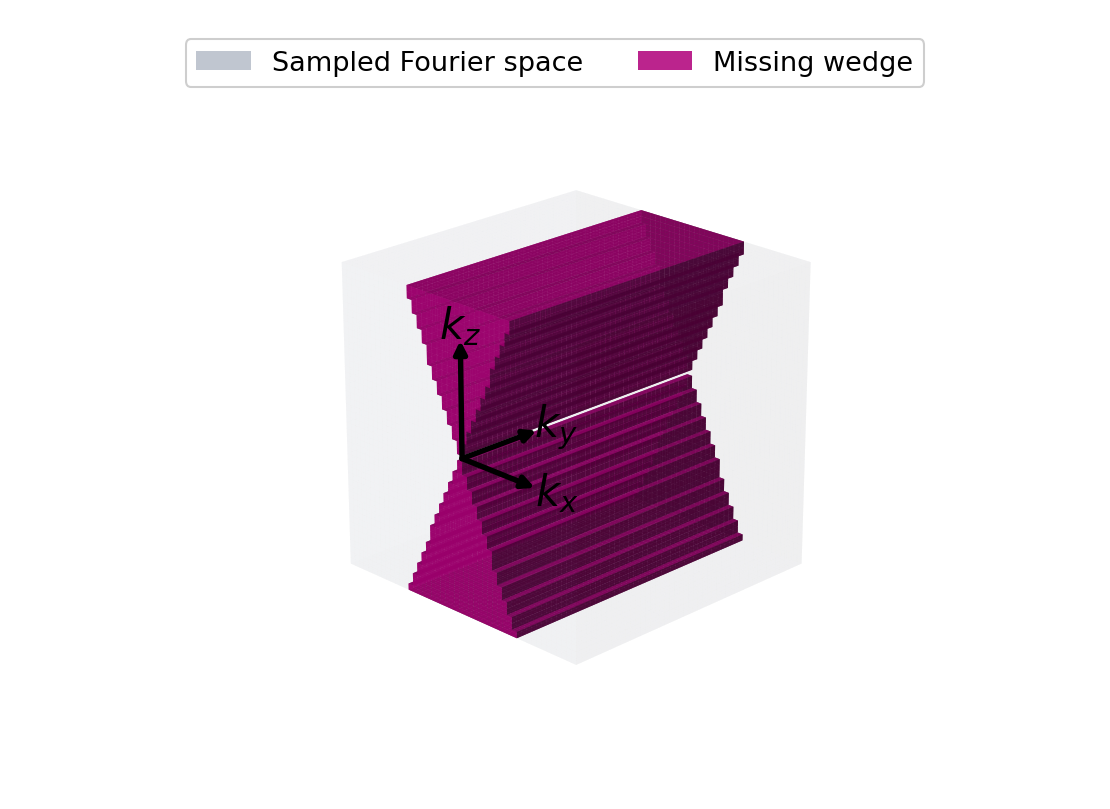

In [18]:
# Presentation-ready 3D missing wedge figure
# Filled voxel wedge + legend outside + FRONT overlay axes with arrows and labels

import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from matplotlib.patches import Patch
from mpl_toolkits.mplot3d import proj3d
from ddw.utils.missing_wedge import get_missing_wedge_mask

# -----------------------------
# Settings
# -----------------------------
angle = 50
grid_size = (48, 48, 48)   # [z, y, x]; moderate for voxel rendering

export_dir = Path("../../figures/final_presentation")
export_dir.mkdir(parents=True, exist_ok=True)

save_png = export_dir / f"missing_wedge_3D_voxels_axes_front_{angle}deg.png"
save_pdf = export_dir / f"missing_wedge_3D_voxels_axes_front_{angle}deg.pdf"

# -----------------------------
# Load missing wedge mask
# -----------------------------
mask = get_missing_wedge_mask(grid_size, mw_angle=angle)

if hasattr(mask, "cpu"):
    mask_np = mask.cpu().numpy()
else:
    mask_np = np.asarray(mask)

# DDW convention:
# mask = 1 -> sampled Fourier space
# mask = 0 -> missing wedge
missing = (1 - mask_np).astype(bool)
sampled = mask_np.astype(bool)

# matplotlib voxels expects [x, y, z]
# DDW / numpy mask is [z, y, x]
missing_vox = np.transpose(missing, (2, 1, 0))
sampled_vox = np.transpose(sampled, (2, 1, 0))

nx, ny, nz = missing_vox.shape

# -----------------------------
# Plot style
# -----------------------------
plt.rcParams.update({
    "font.size": 12,
    "savefig.dpi": 300,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

fig = plt.figure(figsize=(7.2, 5.2))
ax = fig.add_subplot(111, projection="3d")

# -----------------------------
# Voxel rendering
# -----------------------------
# sampled Fourier space: faint background
ax.voxels(
    sampled_vox,
    facecolors=(76/255, 93/255, 122/255, 0.035),
    edgecolor="none"
)

# missing wedge: magenta filled volume
ax.voxels(
    missing_vox,
    facecolors=(176/255, 0/255, 122/255, 0.86),
    edgecolor="none"
)

# -----------------------------
# 3D axes settings
# -----------------------------
ax.set_xlim(0, nx)
ax.set_ylim(0, ny)
ax.set_zlim(0, nz)

ax.set_box_aspect((1, 1, 1))
ax.view_init(elev=22, azim=-45)
ax.set_axis_off()

# -----------------------------
# Legend outside plot
# -----------------------------
legend_handles = [
    Patch(facecolor="#4C5D7A", edgecolor="none", alpha=0.35, label="Sampled Fourier space"),
    Patch(facecolor="#B0007A", edgecolor="none", alpha=0.86, label="Missing wedge"),
]

fig.legend(
    handles=legend_handles,
    loc="upper center",
    bbox_to_anchor=(0.5, 0.985),
    ncol=2,
    frameon=True,
    framealpha=0.95,
    fontsize=13
)

plt.subplots_adjust(top=0.84)

# -----------------------------
# Projection helper
# -----------------------------
def project_point_to_figure_fraction(ax, point3d):
    """
    Project a 3D point in data coordinates to figure-fraction coordinates.
    Returns (x_fig, y_fig) in [0,1]x[0,1].
    """
    x, y, z = point3d

    x2, y2, _ = proj3d.proj_transform(x, y, z, ax.get_proj())
    display_xy = ax.transData.transform((x2, y2))
    fig_xy = ax.figure.transFigure.inverted().transform(display_xy)

    return fig_xy

# Important: update projection after layout is final
fig.canvas.draw()

# -----------------------------
# Overlay axes for front arrows
# -----------------------------
# This invisible axes covers the whole figure and sits on top.
overlay = fig.add_axes([0, 0, 1, 1], frameon=False)
overlay.set_axis_off()
overlay.set_zorder(1000)

def draw_front_axis(overlay_ax, ax3d, start3d, end3d, label,
                    label_offset=(0.01, 0.01), lw=2.6, fontsize=19):
    """
    Draw axis as 2D overlay on top of figure.
    label_offset in figure/overlay fraction coordinates.
    """
    p0 = project_point_to_figure_fraction(ax3d, start3d)
    p1 = project_point_to_figure_fraction(ax3d, end3d)

    overlay_ax.annotate(
        "",
        xy=p1,
        xytext=p0,
        xycoords="axes fraction",
        textcoords="axes fraction",
        arrowprops=dict(
            arrowstyle="-|>",
            lw=lw,
            color="black",
            shrinkA=0,
            shrinkB=0
        ),
        annotation_clip=False,
    )

    overlay_ax.text(
        p1[0] + label_offset[0],
        p1[1] + label_offset[1],
        label,
        transform=overlay_ax.transAxes,
        fontsize=fontsize,
        color="black",
        ha="center",
        va="center",
        clip_on=False,
    )

# -----------------------------
# Axis geometry
# -----------------------------
cx, cy, cz = nx / 2, ny / 2, nz / 2

# lengths in voxel coordinates
Lx = 0.62 * nx / 2
Ly = 0.62 * ny / 2
Lz = 0.75 * nz / 2


# move axis origin a bit towards the viewer / front
origin = (cx, cy - 0.48 * ny, cz)

end_kx = (origin[0] + Lx, origin[1], origin[2])
end_ky = (origin[0], origin[1] + Ly, origin[2])
end_kz = (origin[0], origin[1], origin[2] + Lz)


# Draw axes + labels in front
draw_front_axis(
    overlay, ax,
    origin, end_kx,
    r"$k_x$",
    label_offset=(0.020, -0.005),
    lw=2.6,
    fontsize=20
)

draw_front_axis(
    overlay, ax,
    origin, end_ky,
    r"$k_y$",
    label_offset=(0.018, 0.006),
    lw=2.6,
    fontsize=20
)

draw_front_axis(
    overlay, ax,
    origin, end_kz,
    r"$k_z$",
    label_offset=(0.000, 0.020),
    lw=2.6,
    fontsize=20
)

# -----------------------------
# Save and show
# -----------------------------
fig.savefig(
    save_png,
    dpi=300,
    bbox_inches="tight",
    pad_inches=0.04,
    facecolor="white"
)

fig.savefig(
    save_pdf,
    bbox_inches="tight",
    pad_inches=0.04,
    facecolor="white"
)

print("Saved:", save_png)
print("Saved:", save_pdf)

plt.show()